In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

X, y = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.9, 0.1],
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [3]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_scores = model.predict_proba(X_test)[:, 1]

In [4]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

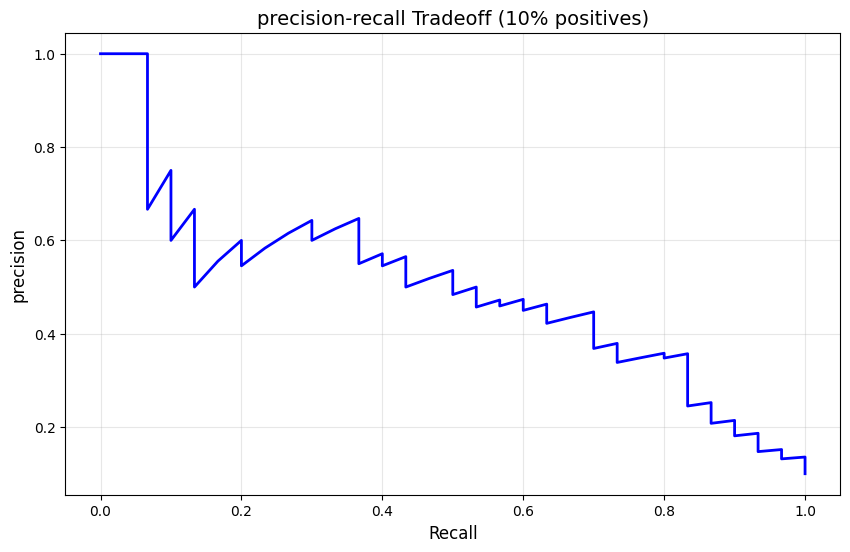

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label='Precision-Recall-Curve', color='blue', linewidth=2)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('precision', fontsize=12)
plt.title('precision-recall Tradeoff (10% positives)',
fontsize=14)
plt.grid(True, alpha=0.3)

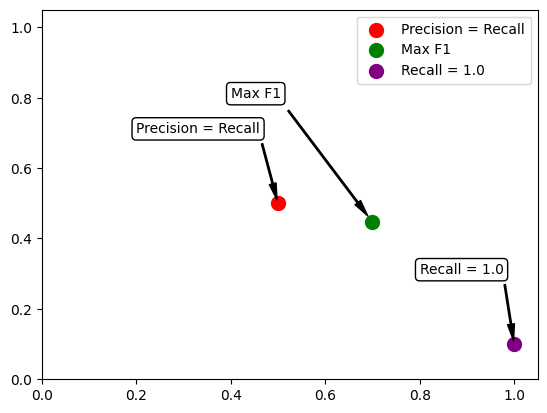

In [6]:
# Find the point where precision = recall
idx_pr_eq = np.argmin(np.abs(precision - recall))
pr_eq_recall = recall[idx_pr_eq]
pr_eq_precision = precision[idx_pr_eq]

# Find the point of maximum F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)  # Avoid division by zero
idx_max_f1 = np.argmax(f1_scores)
max_f1_recall = recall[idx_max_f1]
max_f1_precision = precision[idx_max_f1]

# Find the point where recall = 1.0
idx_recall_1 = np.argmin(np.abs(recall - 1.0))
recall_1_precision = precision[idx_recall_1]

# Mark points on the plot
plt.scatter(pr_eq_recall, pr_eq_precision, color='red', s=100, label='Precision = Recall')
plt.scatter(max_f1_recall, max_f1_precision, color='green', s=100, label='Max F1')
plt.scatter(1.0, recall_1_precision, color='purple', s=100, label='Recall = 1.0')

# Add annotations
plt.annotate(
    'Precision = Recall',
    xy=(pr_eq_recall, pr_eq_precision),
    xytext=(0.2, 0.7),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
)

plt.annotate(
    'Max F1',
    xy=(max_f1_recall, max_f1_precision),
    xytext=(0.4, 0.8),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
)

plt.annotate(
    'Recall = 1.0',
    xy=(1.0, recall_1_precision),
    xytext=(0.8, 0.3),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
)

plt.legend(fontsize=10)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.show()